# DATA 555 Project 1: Medical Insurance Forecast

Dataset: the downloaded `insurance.csv` comes from [Medical Cost Personal Datasets on Kaggle](https://www.kaggle.com/mirichoi0218/insurance/kernels).

The target variable is `charges`, which represents the medical costs billed for an individual.

The analysis uses Python, pandas, matplotlib, and scikit-learn.

Project repository: [GitHub](https://github.com/QihangFeng/data555-project1)

## Data Preparation — Exploration stage

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Data checks and preparation

#### General data checks

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path("insurance.csv")
if not data_path.exists():
    data_url = "https://raw.githubusercontent.com/QihangFeng/data555-project1/main/insurance.csv"
    urlretrieve(data_url, data_path)
    print("Downloaded insurance.csv.")
else:
    print("insurance.csv already exists; using the local file.")

insurance.csv already exists; using the local file.


In [3]:
# Load the provided CSV and display its size and first five records.
insurance = pd.read_csv("insurance.csv")
print(f"Original dataset: {len(insurance):,} rows and {len(insurance.columns)} columns")
display(insurance.head())

Original dataset: 1,338 rows and 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.duplicated(keep=False)

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [5]:
# Check that all seven required columns are present.
expected_columns = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
missing_columns = [column for column in expected_columns if column not in insurance.columns]
print(f"Missing required columns: {missing_columns}")

# Check the data type and number of missing values in each column.
data_validation = pd.DataFrame({
    "Data type": insurance.dtypes.astype(str),
    "Missing values": insurance.isna().sum(axis=0)
})
display(data_validation)

# Count additional copies, excluding the first occurrence of each record.
print(f"Extra duplicate rows: {insurance.duplicated().sum()}")

# Display all copies of repeated records, including the first occurrence.
display(insurance.loc[insurance.duplicated(keep=False)])

Missing required columns: []


,Data type,Missing values
age,int64,0
sex,str,0
bmi,float64,0
children,int64,0
smoker,str,0
region,str,0
charges,float64,0


Extra duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


#### Numerical value checks

In [6]:
# Age should be positive, and age and children should be whole numbers.
# BMI should be positive, and children and charges should not be negative.
numeric_columns = ["age", "bmi", "children", "charges"]
numeric_checks = pd.Series({
    "Invalid age": ((insurance["age"] <= 0) | (insurance["age"] % 1 != 0)).sum(),
    "Invalid children": ((insurance["children"] < 0) | (insurance["children"] % 1 != 0)).sum(),
    "Nonpositive BMI": (insurance["bmi"] <= 0).sum(),
    "Negative charges": (insurance["charges"] < 0).sum(),
    "Infinite numerical values": insurance[numeric_columns].isin([np.inf, -np.inf]).sum().sum()
}, name="Count")
display(numeric_checks.to_frame())

,Count
Invalid age,0
Invalid children,0
Nonpositive BMI,0
Negative charges,0
Infinite numerical values,0


In [7]:
# Inspect the ranges and middle values without treating large values as errors.
display(insurance[numeric_columns].describe().round(2))

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


#### Categorical label checks

In [8]:
# Check labels against the categories described by the dataset source.
expected_categories = {
    "sex": ["female", "male"],
    "smoker": ["no", "yes"],
    "region": ["northeast", "northwest", "southeast", "southwest"]
}
category_checks = []
for column, expected in expected_categories.items():
    # Remove leading and trailing spaces and use lowercase letters for comparison.
    normalized_labels = insurance[column].str.strip().str.lower()
    category_checks.append({
        "Column": column,
        "Observed labels": insurance[column].unique().tolist(),
        "Unexpected labels": (~insurance[column].isin(expected)).sum(),
        "Spacing/capitalization issues": (insurance[column] != normalized_labels).sum()
    })
display(pd.DataFrame(category_checks).set_index("Column"))

,Observed labels,Unexpected labels,Spacing/capitalization issues
Column,,,
sex,"[female, male]",0,0
smoker,"[yes, no]",0,0
region,"[southwest, southeast, northwest, northeast]",0,0


#### Remove repeated records

In [9]:
# Treat identical rows as repeated records and keep the first copy.
# The original insurance DataFrame and CSV remain available.
data = insurance.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Rows removed: {len(insurance) - len(data)}")
print(f"Cleaned data: {len(data):,} rows")
print(f"Missing values after cleaning: {data.isna().sum().sum()}")
print(f"Extra duplicate rows after cleaning: {data.duplicated().sum()}")

Rows removed: 1
Cleaned data: 1,337 rows
Missing values after cleaning: 0
Extra duplicate rows after cleaning: 0


All seven required columns are present, and the checks found no missing values, invalid numerical values, unexpected category labels, or labels needing changes to spacing or capitalization. For this project, I treat identical rows as repeated records and remove one extra copy, leaving 1,337 records. I keep the high medical charges because a large value alone does not show that a record is incorrect.

#### Keep records for testing

I use 80% of the cleaned records to train and compare the models and keep 20% to test the selected model. Using `random_state=42` makes the split repeatable, while `stratify=data["smoker"]` keeps similar proportions of smokers and nonsmokers in both groups. The exploratory plots below use only the training records.

In [10]:
# Reserve a test set and preserve the smoking proportions.
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["smoker"]
)
print(f"Training records: {len(train_data):,}")
print(f"Test records: {len(test_data):,}")
display(train_data["smoker"].value_counts().rename("Training count").to_frame())

Training records: 1,069
Test records: 268


,Training count
smoker,
no,850
yes,219


In [11]:
# The 50% row is the median.
print("Numerical training data:")
display(train_data[numeric_columns].describe().round(2))

# Summarize category counts, unique labels, and the most common label.
print("Categorical training data:")
display(train_data[["sex", "smoker", "region"]].describe())

Numerical training data:


,age,bmi,children,charges
count,1069.00,1069.00,1069.00,1069.00
mean,39.06,30.82,1.09,13355.93
std,14.05,6.09,1.18,12135.07
min,18.00,15.96,0.00,1121.87
25%,26.00,26.41,0.00,4753.64
50%,39.00,30.50,1.00,9414.92
75%,51.00,34.80,2.00,17178.68
max,64.00,53.13,5.00,63770.43


Categorical training data:


,sex,smoker,region
count,1069,1069,1069
unique,2,2,4
top,male,no,southeast
freq,547,850,293


### Exploratory data analysis

#### Distribution of medical charges

**The rationale of selecting this plot:** I chose a histogram because knowing which medical charge ranges are common gives context for judging whether the model's prediction errors are small or large.

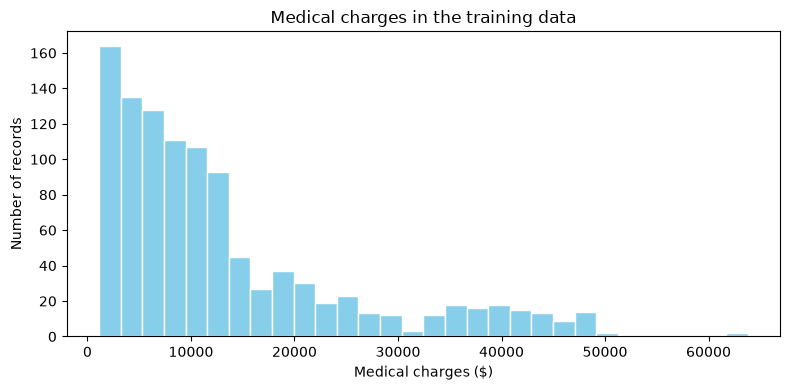

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_data["charges"], bins=30, color="skyblue", edgecolor="white")
ax.set_title("Medical charges in the training data")
ax.set_xlabel("Medical charges ($)")
ax.set_ylabel("Number of records")
fig.tight_layout()
plt.show()

**My interpretation:** Most training records have medical charges below about $15,000, while a smaller number have charges above $50,000. The long tail toward higher charges shows that the distribution is skewed to the right.

#### Medical charges by smoking status

**The rationale of selecting this plot:** I chose a box plot because differences in the median and variation of charges between smokers and nonsmokers help me assess whether smoking status is useful for predicting medical charges.

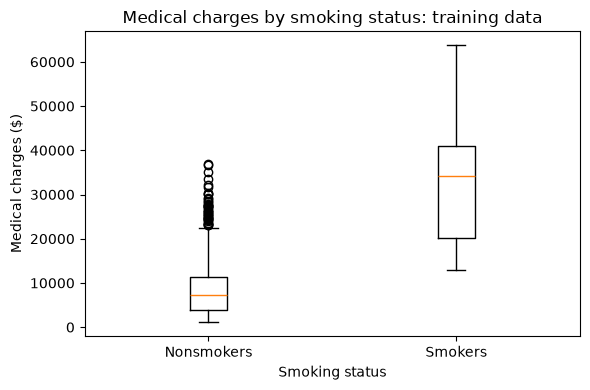

,count,median,mean
smoker,,,
no,850,7351.95,8568.28
yes,219,34254.05,31938.13


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [
        train_data.loc[train_data["smoker"] == "no", "charges"],
        train_data.loc[train_data["smoker"] == "yes", "charges"]
    ],
    tick_labels=["Nonsmokers", "Smokers"]
)
ax.set_title("Medical charges by smoking status: training data")
ax.set_xlabel("Smoking status")
ax.set_ylabel("Medical charges ($)")
fig.tight_layout()
plt.show()

# Show the group sizes and charges to support the plot interpretation.
display(
    train_data.groupby(by="smoker")["charges"]
    .agg(["count", "median", "mean"])
    .round(2)
)

**My interpretation:** Smokers have a much higher median medical charge, about $34,000 compared with about $7,000 for nonsmokers. Charges vary more widely among smokers, while several nonsmoker records also have high charges.

#### Age and BMI relationships

**The rationale of selecting this plot:** I chose scatter plots because the shapes of the relationships between age and medical charges and between BMI and medical charges help me decide whether multiple linear regression is suitable and whether to include a BMI and smoking interaction.

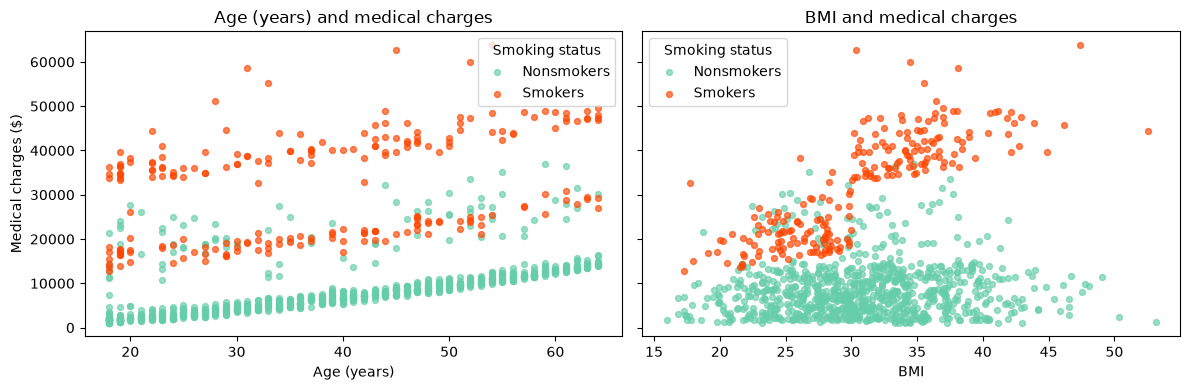

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for column, axis_label, ax in zip(["age", "bmi"], ["Age (years)", "BMI"], axes):
    for status, colour, label in [
        ("no", "mediumaquamarine", "Nonsmokers"),
        ("yes", "orangered", "Smokers")
    ]:
        group = train_data.loc[train_data["smoker"] == status]
        ax.scatter(
            group[column], group["charges"],
            s=18, alpha=0.65, color=colour, label=label
        )
    ax.set_xlabel(axis_label)
    ax.set_title(f"{axis_label} and medical charges")
    ax.legend(title="Smoking status")
axes[0].set_ylabel("Medical charges ($)")
fig.tight_layout()
plt.show()

**My interpretation:** For the age and medical charges plot, charges generally increase with age for both smokers and nonsmokers. For the BMI and medical charges plot, charges generally increase with BMI among smokers, while nonsmokers show little overall change in charges as BMI increases.

## Regression Analysis — Execution stage

### Regression model and categorical predictors

I use multiple linear regression to predict medical charges from age, BMI, number of children, sex, smoking status, and region. This model is suitable because charges are continuous numerical values and several predictors can be considered together.

The scatter plot shows that charges increase more clearly with BMI among smokers than among nonsmokers. I therefore compare the basic multiple linear regression model with another multiple linear regression model that includes a BMI and smoking interaction. As BMI increases, this second model can predict a small increase in charges for nonsmokers and a larger increase for smokers. I add the extra predictor `bmi_smoker`, calculated as `(bmi - 30) * smoker_yes`, which is zero for nonsmokers and `bmi - 30` for smokers.

I choose 30 because it is a simple round number close to the training records' median BMI of 30.5. Subtracting 30 makes the extra predictor `bmi_smoker` equal to zero at BMI 30, so we can directly compare the model's predictions for a smoker and a nonsmoker who both have BMI 30. The two people also have the same age, sex, number of children, and region. In this comparison, the number learned for `smoker_yes` tells us how much higher or lower the predicted medical charges are for the smoker than for the nonsmoker.

The categorical predictors are `sex`, `smoker`, and `region`. The model needs numerical inputs, so I replace their text labels with columns containing 0 or 1.

- **Sex:** I create `sex_male`, where 1 means male and 0 means female.
- **Smoking status:** I create `smoker_yes`, where 1 means smoker and 0 means nonsmoker.

Region has four categories, so one column containing only 0 or 1 cannot identify all four. I use three columns, with 1 meaning the person belongs to the region named in that column and 0 meaning the person does not:

| Original region | `region_northwest` | `region_southeast` | `region_southwest` |
|---|---:|---:|---:|
| northeast | 0 | 0 | 0 |
| northwest | 1 | 0 | 0 |
| southeast | 0 | 1 | 0 |
| southwest | 0 | 0 | 1 |

In [15]:
# Separate medical charges from the predictors.
# Represent sex, smoking status, and region using columns containing 0 or 1.
categorical_columns = ["sex", "smoker", "region"]
X_train = pd.get_dummies(
    train_data.drop(columns="charges"),
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)
X_test = pd.get_dummies(
    test_data.drop(columns="charges"),
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Keep the test predictor columns in the same order as the training columns.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = train_data["charges"]
y_test = test_data["charges"]
display(X_train.head())

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
367,42,24.985,2,0,0,1,0,0
418,64,39.160,1,1,0,0,1,0
938,53,29.480,0,1,0,0,1,0
533,37,36.190,0,1,0,0,1,0
354,18,38.280,0,0,0,0,1,0


### Compare the models using training records

Five-fold cross-validation divides the training records into five parts. Each model is trained on four parts and evaluated on the remaining part, repeating the process until each part has been used for evaluation. I compare the average results and select the model with the lowest RMSE, which measures prediction error in dollars and gives more weight to large errors.

In [16]:
# Add the BMI and smoking interaction suggested by the scatter plot.
X_train_interaction = X_train.copy()
X_train_interaction["bmi_smoker"] = (
    (X_train_interaction["bmi"] - 30) * X_train_interaction["smoker_yes"]
)
feature_sets = {
    "Basic multiple linear regression": X_train,
    "Multiple linear regression with interaction": X_train_interaction
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Use the same five parts for both models and average their evaluation results.
cv_rows = []
for model_name, predictors in feature_sets.items():
    scores = cross_validate(
        LinearRegression(),
        predictors,
        y_train,
        cv=cv,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        }
    )
    # scikit-learn returns negative error scores; reverse their signs to report errors.
    cv_rows.append({
        "Model": model_name,
        "Validation R²": scores["test_r2"].mean(),
        "Validation RMSE ($)": -scores["test_rmse"].mean(),
        "Validation MAE ($)": -scores["test_mae"].mean()
    })
cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results.round({
    "Validation R²": 3, "Validation RMSE ($)": 2, "Validation MAE ($)": 2
}))

# Select the model with the lowest average validation RMSE.
best_model_name = cv_results["Validation RMSE ($)"].idxmin()
print(f"Selected model: {best_model_name}")

,Validation R²,Validation RMSE ($),Validation MAE ($)
Model,,,
Basic multiple linear regression,0.722,6297.12,4392.59
Multiple linear regression with interaction,0.819,5050.49,3132.98


Selected model: Multiple linear regression with interaction


The multiple linear regression model with the BMI and smoking interaction has a lower average validation RMSE, about $5,050 compared with $6,297 for the basic model. Its average validation R² is also higher, increasing from 0.722 to 0.819. I therefore select the multiple linear regression model with the interaction before evaluating the test records.

### Train the selected model and check its predictions

#### 1. Overview

I trained the selected model on all training records and used it to predict medical charges for each test record. I then compared the predictions with the actual charges.

#### 2. Evaluation metrics

R², RMSE, and MAE are evaluation metrics: numbers that help us judge prediction accuracy. In the formulas below:

- $y_i$ is the actual charge for record $i$.
- $\hat{y}_i$ is its predicted charge.
- $n$ is the number of records being evaluated.
- $\bar{y}$ is the average actual charge of those records.
- $\sum_{i=1}^{n}$ means add the result for every record.

**R²: comparison with predicting the average**

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

The top sum is the model's total squared prediction error. The bottom sum is the total squared error from predicting the average charge for everyone. Higher R² means smaller errors compared with that average prediction. R² is 1 for perfect predictions, 0 for no improvement, and negative for worse predictions.

**RMSE: root mean squared error**

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

This squares each prediction error, averages the squares, and takes the square root. Squaring means multiplying an error by itself, which makes large errors contribute more strongly. RMSE is reported in dollars, and lower values are better.

**MAE: mean absolute error**

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

The vertical bars turn negative errors into positive amounts and leave positive errors unchanged. Averaging these amounts gives the average prediction error in dollars. Lower MAE is better.

#### 3. Compare with a simple average-charge prediction

I calculated the training records' average charge, about \$13,356, and used it as the prediction for every test record. This method makes the same prediction for everyone, regardless of their age, BMI, or smoking status. Comparing its errors with the regression model's errors shows whether using each person's information makes predictions more accurate. The test RMSE was about \$12,013 for this simple method and \$3,906 for regression, so the regression model performed better.

In [17]:
# Train the selected model using the training records only.
X_train_final = feature_sets[best_model_name]
X_test_final = X_test.copy()
if best_model_name == "Multiple linear regression with interaction":
    X_test_final["bmi_smoker"] = (
        (X_test_final["bmi"] - 30) * X_test_final["smoker_yes"]
    )
model = LinearRegression()
model.fit(X_train_final, y_train)
train_prediction = model.predict(X_train_final)
test_prediction = model.predict(X_test_final)

# Predict the same training mean charge for every test record as a comparison.
mean_prediction = np.full(len(y_test), y_train.mean())

# Calculate R², RMSE, and MAE for each set of predictions.
metric_rows = []
for label, actual, predicted in [
    ("Selected model: training", y_train, train_prediction),
    ("Selected model: test", y_test, test_prediction),
    ("Training mean: test", y_test, mean_prediction)
]:
    metric_rows.append({
        "Evaluation": label,
        "R²": r2_score(actual, predicted),
        "RMSE ($)": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE ($)": mean_absolute_error(actual, predicted)
    })
metrics = pd.DataFrame(metric_rows).set_index("Evaluation")
display(metrics.round({"R²": 3, "RMSE ($)": 2, "MAE ($)": 2}))

# Medical charges cannot be negative, so check for negative predictions.
print(f"Negative test predictions: {(test_prediction < 0).sum()}")

,R²,RMSE ($),MAE ($)
Evaluation,,,
Selected model: training,0.827,5044.67,3100.71
Selected model: test,0.894,3905.65,2593.96
Training mean: test,-0.001,12012.59,9080.77


Negative test predictions: 0


### Interpret the fitted coefficients

A coefficient describes the change in predicted charges when its predictor increases by one unit and the other predictors stay the same. For a category column containing 0 or 1, the coefficient describes the difference from the comparison group. In the model with the interaction, the `bmi` coefficient describes nonsmokers, and the `bmi_smoker` coefficient gives the additional change per BMI unit for smokers.

In [18]:
# Show how each predictor contributes to predicted medical charges.
coefficients = pd.Series(
    model.coef_, index=X_train_final.columns, name="Coefficient ($)"
)
print(f"Intercept: {model.intercept_:,.2f}")
display(coefficients.round(2).to_frame())

# Calculate the predicted charge change for each additional BMI unit.
print(f"Change per BMI unit for nonsmokers: ${coefficients['bmi']:,.2f}")
if "bmi_smoker" in coefficients.index:
    smoker_bmi_change = coefficients["bmi"] + coefficients["bmi_smoker"]
    print(
        f"Change per BMI unit for smokers: ${coefficients["bmi"]:,.2f} + ${coefficients["bmi_smoker"]:,.2f} = ${smoker_bmi_change:,.2f}"
    )
    print(
        f"Predicted smoking-group difference at BMI 30: ${coefficients['smoker_yes']:,.2f}"
    )

Intercept: -1,513.35


,Coefficient ($)
age,256.59
bmi,16.53
children,602.04
sex_male,-721.07
smoker_yes,22603.98
region_northwest,-571.62
region_southeast,-1286.76
region_southwest,-1356.07
bmi_smoker,1502.79


Change per BMI unit for nonsmokers: $16.53
Change per BMI unit for smokers: $16.53 + $1,502.79 = $1,519.31
Predicted smoking-group difference at BMI 30: $22,603.98


For each comparison below, the person's other information stays the same.

- **Age (`age`):** When age increases by 1 year, the model predicts that medical charges increase by about \$257.
- **BMI (`bmi`):** For a nonsmoker, when BMI increases by 1 unit, the model predicts that medical charges increase by about \$17.
- **BMI and smoking (`bmi_smoker`):** For a smoker, when BMI increases by 1 unit, the model adds \$16.53 from the BMI coefficient and \$1,502.79 from this coefficient. The total predicted increase in charges is about \$1,519.
- **Number of children (`children`):** When the number of children increases by 1, the model predicts that medical charges increase by about \$602.
- **Sex (`sex_male`):** The model predicts charges about \$721 lower for a male than for a female.
- **Smoking status (`smoker_yes`):** At BMI 30, the model predicts charges about \$22,600 higher for a smoker than for a nonsmoker. The two people have the same age, sex, number of children, and region.
- **Northwest (`region_northwest`):** The model predicts charges about \$572 lower for someone in the northwest than for someone in the northeast.
- **Southeast (`region_southeast`):** The model predicts charges about \$1,287 lower for someone in the southeast than for someone in the northeast.
- **Southwest (`region_southwest`):** The model predicts charges about \$1,356 lower for someone in the southwest than for someone in the northeast.

These coefficients show statistical relationships between the predictors and medical charges, but they do not prove that changing a predictor causes a person's actual medical charges to change.

### Model fit and residuals on the test data

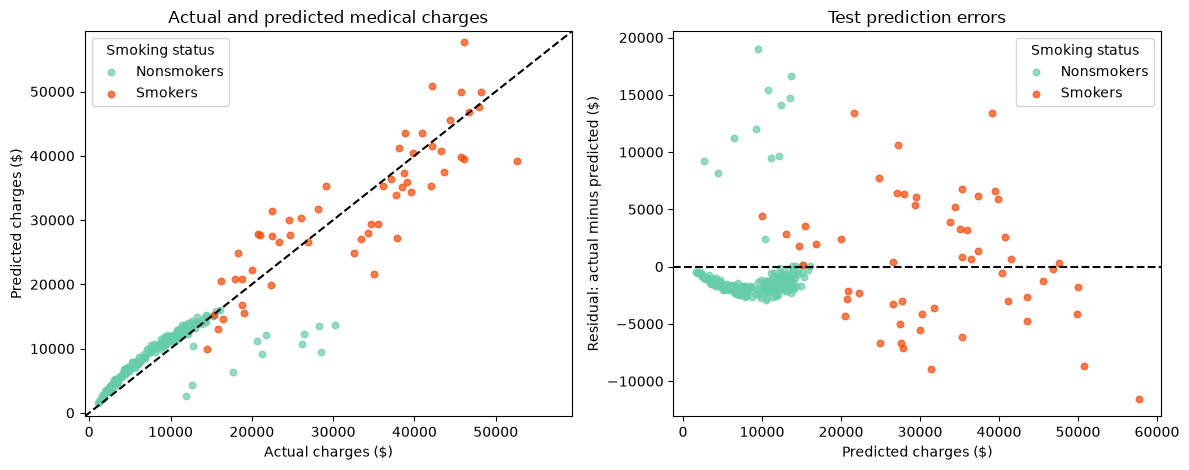

In [19]:
# A residual is the actual charge minus the predicted charge.
# Positive residuals mean the model predicted too low; negative ones mean too high.
residuals = y_test - test_prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for status, colour, label in [
    ("no", "mediumaquamarine", "Nonsmokers"),
    ("yes", "orangered", "Smokers")
]:
    mask = test_data["smoker"] == status
    axes[0].scatter(
        y_test[mask], test_prediction[mask],
        s=22, alpha=0.70, color=colour, label=label
    )
    axes[1].scatter(
        test_prediction[mask], residuals[mask],
        s=22, alpha=0.70, color=colour, label=label
    )

# Points on the diagonal represent predictions equal to the actual charges.
plot_min = min(y_test.min(), test_prediction.min())
plot_max = max(y_test.max(), test_prediction.max())
padding = (plot_max - plot_min) * 0.03
limits = [plot_min - padding, plot_max + padding]
axes[0].plot(limits, limits, color="black", linestyle="--")
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_title("Actual and predicted medical charges")
axes[0].set_xlabel("Actual charges ($)")
axes[0].set_ylabel("Predicted charges ($)")
axes[0].legend(title="Smoking status")

# Points on the horizontal zero line have no prediction error.
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Test prediction errors")
axes[1].set_xlabel("Predicted charges ($)")
axes[1].set_ylabel("Residual: actual minus predicted ($)")
axes[1].legend(title="Smoking status")
fig.tight_layout()
plt.show()

**Left plot — Actual and predicted charges**

- **Meaning of the points:** Each point represents one test record: its horizontal position shows actual charges, and its vertical position shows predicted charges. A point on the dashed diagonal line is a perfect prediction.
- **What the model does well:** Many points, especially nonsmokers with lower charges, lie close to the diagonal line, so their predicted charges are close to their actual charges.
- **Shortcomings:** Some points fall far below the line, showing that the model predicts charges much too low for these records. Points above the line show that the model predicts charges too high for other records.

**Right plot — Prediction errors**

- **Meaning of the points:** Each point represents one test record: its horizontal position shows predicted charges, and its vertical position shows the error, calculated as actual charges minus predicted charges. Points above zero mean the prediction is too low, points below zero mean it is too high, and points on zero are perfect predictions.
- **What the model does well:** Many nonsmoker points lie close to zero, showing that their predicted charges are close to their actual charges.
- **Shortcomings:** Many nonsmoker points form a curved band below zero, showing that the model repeatedly predicts charges too high for these records. A few positive errors approach \$20,000, showing that some predictions are much too low.